In [38]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

### **Часть 1**

In [39]:
df = pd.read_csv('datasets/data_ab.csv')

In [40]:
df['user_id'].unique()

array([851104, 804228, 661590, ..., 734608, 697314, 715931],
      shape=(290584,))

In [54]:
df.shape

(294478, 5)

In [42]:
df.shape[0] - df['user_id'].unique().shape[0]

3894

    Видно, что некоторым людям дважды показывали страницу
    

In [45]:
df_duplicates = df[df.duplicated('user_id')]

In [51]:
un_dup = df_duplicates['user_id'].unique()
s = set(un_dup)


In [56]:
d_non_un = []
for i in df.values:
    if np.int64(i[0]) in s:
        d_non_un.append(i)

In [57]:
data_nunique = pd.DataFrame(d_non_un)

In [58]:
data_nunique = data_nunique.rename(columns={0:'user_id', 1:'date', 2:'group', 3:'landing_page', 4:'coverted'})

In [ ]:
data_nunique = data_nunique.sort_values('user_id')

In [60]:
incorrect = data_nunique[((data_nunique['group'] == 'control') & (data_nunique['landing_page'] == 'new_page')) | ((data_nunique['group'] == 'treatment') & (data_nunique['landing_page'] == 'old_page'))]

In [61]:
incorrect.shape

(3893, 5)

Видим, что некорректных данных - строк, в которых не совпадает группа и показанная страница (например ```group``` == ```control``` и ```landing_pag``` == ```new_page```) - почти столько же, сколько совпадений, поэтому удалим эти некорректные данные

In [86]:
correct_data = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) | ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

In [87]:
a = correct_data[correct_data.duplicated('user_id')]

In [88]:
a

,user_id,timestamp,group,landing_page,converted
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0


In [89]:
b = correct_data[correct_data['user_id'] == 773192]
b

,user_id,timestamp,group,landing_page,converted
1899,773192,2025-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0


    тут уже просто дупликат, возьмем первый показ

In [91]:
correct_data = correct_data.sort_values('timestamp')

In [92]:
cor_data = correct_data.drop_duplicates('user_id')
cor_data

,user_id,timestamp,group,landing_page,converted
131228,922696,2025-01-02 13:42:05.378582,treatment,new_page,0
184884,781507,2025-01-02 13:42:15.234051,control,old_page,0
83878,737319,2025-01-02 13:42:21.786186,control,old_page,0
102717,818377,2025-01-02 13:42:26.640581,treatment,new_page,0
158789,725857,2025-01-02 13:42:27.851110,treatment,new_page,0
...,...,...,...,...,...
158814,799244,2025-01-24 13:41:15.325359,treatment,new_page,0
47535,808330,2025-01-24 13:41:19.152664,control,old_page,0
157787,843121,2025-01-24 13:41:44.097174,treatment,new_page,0
179072,836373,2025-01-24 13:41:52.604673,control,old_page,0


In [93]:
group_a = cor_data[cor_data['group'] == 'control']
group_b = cor_data[cor_data['group'] == 'treatment']

In [94]:
len(group_a), len(group_b)

(145274, 145310)

In [99]:
d_for_g = pd.DataFrame({
    'conversion': [group_a['converted'].sum()/len(group_a), group_b['converted'].sum()/len(group_b)]
}, index=['A', 'B'])

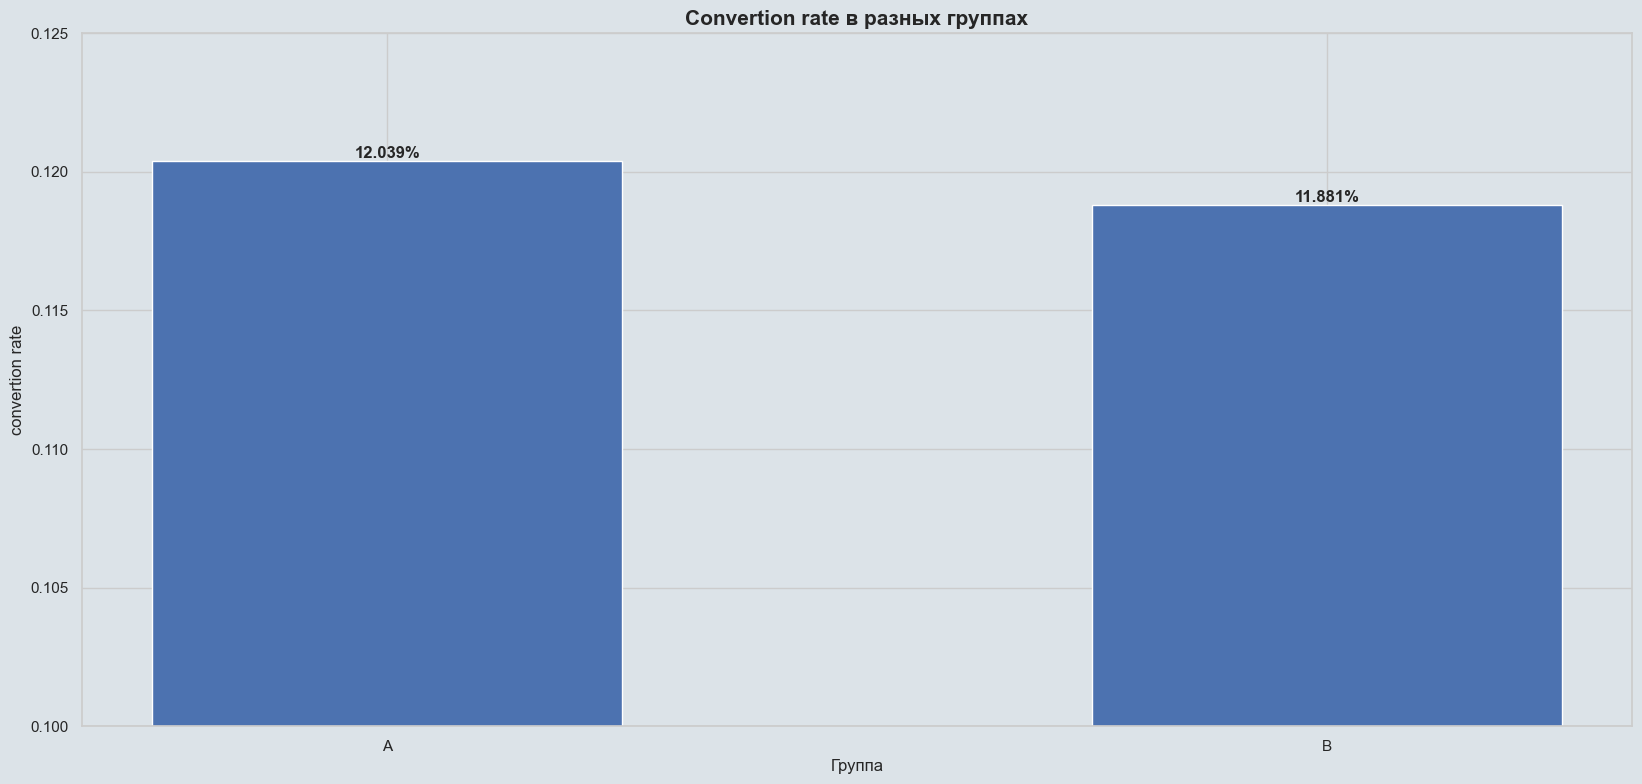

In [165]:
plt.figure(figsize=(20, 9))
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#DCE3E8", 
    "axes.facecolor": "#DCE3E8"     
})
plt.title('Convertion rate в разных группах', fontweight='bold', fontsize=15)
plt.xlabel('Группа')
plt.ylabel('convertion rate')
bars = plt.bar(d_for_g.index, d_for_g['conversion'], width=0.5)
plt.bar_label(bars, labels=[f'{round(x*100, 3)}%' for x in d_for_g['conversion']], fontsize=12, fontweight='bold')
plt.ylim(0.1, 0.125)
plt.show()

    Проверим равномерность распределения показов по времени, а именно, по дням, часам внутри для, и минутам

In [124]:
timestamps = pd.read_csv('datasets/timestamps.csv', index_col=0)

In [125]:
timestamps

,timestamp,group,year,month,day,day_of_the_week,hour,minute,coverted
0,2025-01-21 22:11:48.556739,control,2025,1,21,day,22,11,0
1,2025-01-12 08:01:45.159739,control,2025,1,12,day,8,1,0
2,2025-01-11 16:55:06.154213,treatment,2025,1,11,day,16,55,0
3,2025-01-08 18:28:03.143765,treatment,2025,1,8,day,18,28,0
4,2025-01-21 01:52:26.210827,control,2025,1,21,day,1,52,1
...,...,...,...,...,...,...,...,...,...
290579,2025-01-17 15:43:17.255322,treatment,2025,1,17,day,15,43,1
290580,2025-01-08 22:56:13.599712,control,2025,1,8,day,22,56,0
290581,2025-01-18 06:39:31.294688,control,2025,1,18,day,6,39,0
290582,2025-01-13 17:23:21.750962,control,2025,1,13,day,17,23,0


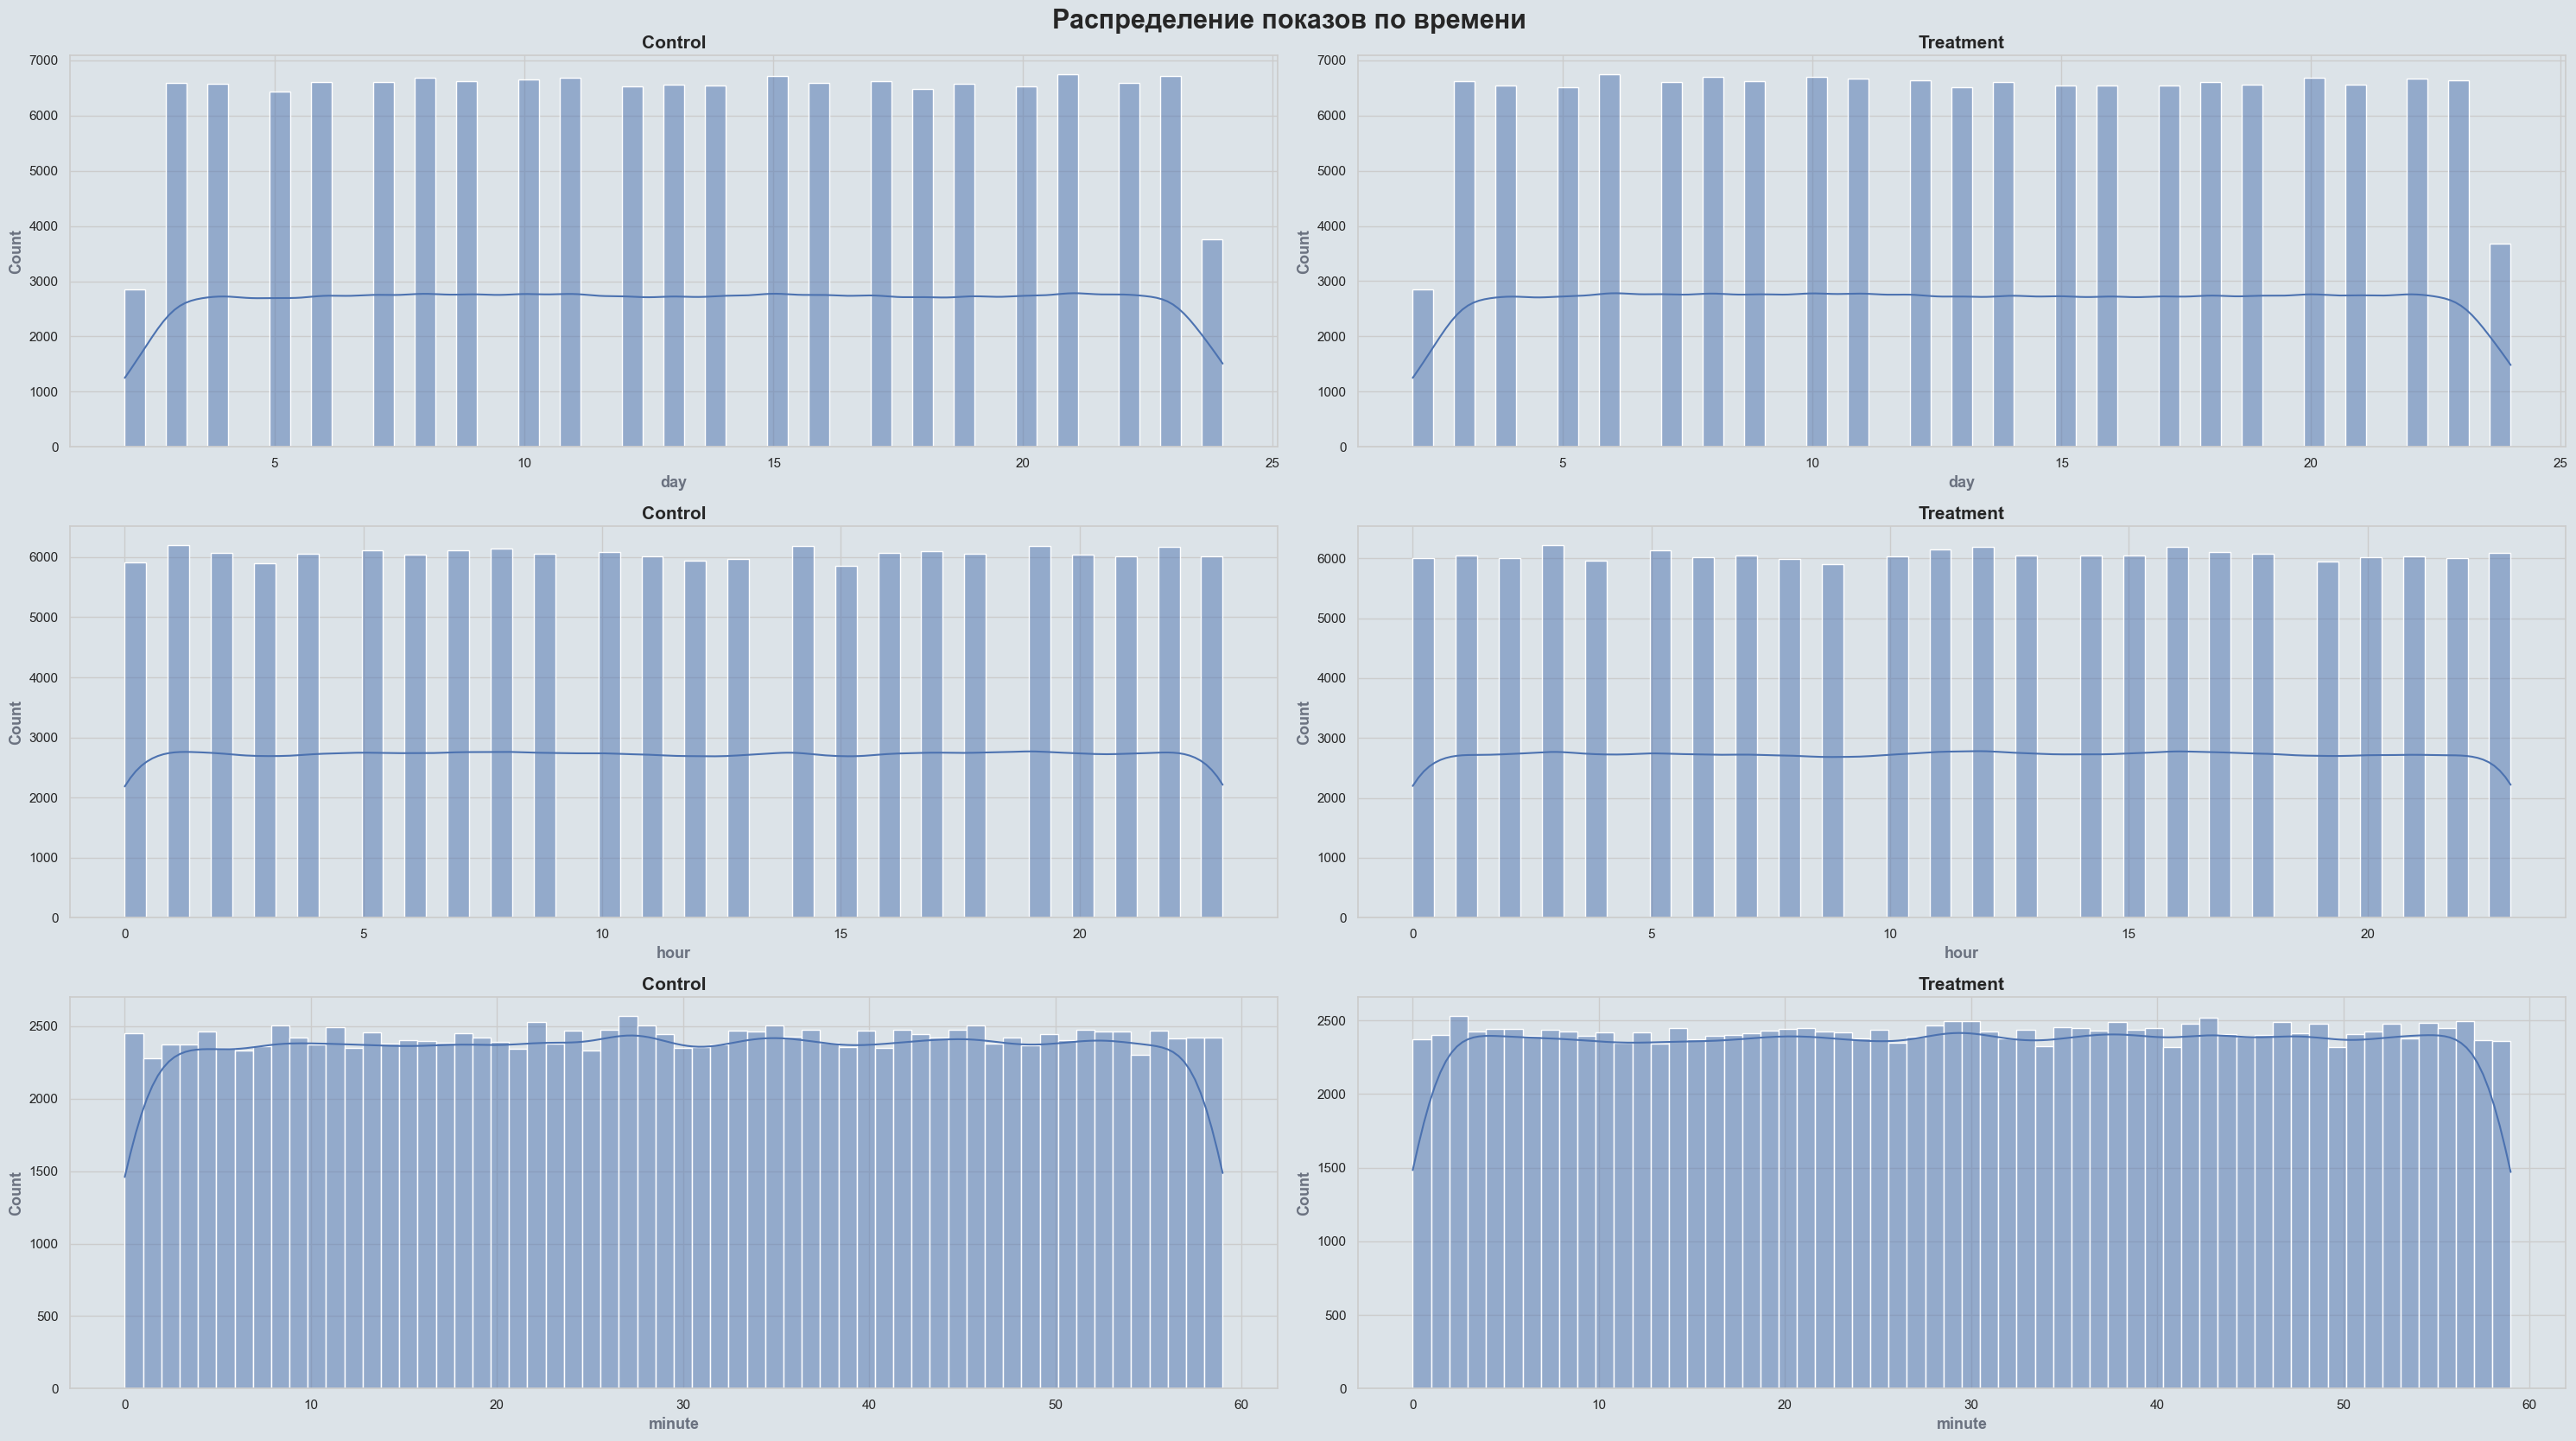

In [ ]:
plt.figure(figsize=(30, 17))

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#DCE3E8", 
    "axes.facecolor": "#DCE3E8"     
})

plt.suptitle(
    "Распределение показов по времени",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

A_times = timestamps[timestamps.group == 'control']
B_times = timestamps[timestamps.group == 'treatment']

plt.subplot(3,2,1)
ax = plt.gca()
sns.histplot(data = A_times, x = 'day', kde=True)
plt.title('Control', fontsize=15, fontweight="bold")
ax.xaxis.label.set_fontweight("bold")
ax.yaxis.label.set_fontweight("bold")
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)
ax.xaxis.label.set_color("#6B7280")
ax.yaxis.label.set_color("#6B7280")

plt.subplot(3,2,2)
ax = plt.gca()
sns.histplot(data = B_times, x = 'day', kde=True)
plt.title('Treatment', fontsize=15, fontweight="bold")
ax.xaxis.label.set_fontweight("bold")
ax.yaxis.label.set_fontweight("bold")
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)
ax.xaxis.label.set_color("#6B7280")
ax.yaxis.label.set_color("#6B7280")

plt.subplot(3,2,3)
ax = plt.gca()
sns.histplot(data = A_times, x = 'hour', kde=True)
plt.title('Control', fontsize=15, fontweight="bold")
ax.xaxis.label.set_fontweight("bold")
ax.yaxis.label.set_fontweight("bold")
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)
ax.xaxis.label.set_color("#6B7280")
ax.yaxis.label.set_color("#6B7280")

plt.subplot(3,2,4)
ax = plt.gca()
sns.histplot(data = B_times, x = 'hour', kde=True)
plt.title('Treatment', fontsize=15, fontweight="bold")
ax.xaxis.label.set_fontweight("bold")
ax.yaxis.label.set_fontweight("bold")
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)
ax.xaxis.label.set_color("#6B7280")
ax.yaxis.label.set_color("#6B7280")

plt.subplot(3,2,5)
ax = plt.gca()
sns.histplot(data = A_times, x = 'minute', bins=60, kde=True)
plt.title('Control', fontsize=15, fontweight="bold")
ax.xaxis.label.set_fontweight("bold")
ax.yaxis.label.set_fontweight("bold")
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)
ax.xaxis.label.set_color("#6B7280")
ax.yaxis.label.set_color("#6B7280")

plt.subplot(3,2,6)
ax = plt.gca()
sns.histplot(data = B_times, x = 'minute', bins=60, kde=True)
plt.title('Treatment', fontsize=15, fontweight="bold")
ax.xaxis.label.set_fontweight("bold")
ax.yaxis.label.set_fontweight("bold")
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)
ax.xaxis.label.set_color("#6B7280")
ax.yaxis.label.set_color("#6B7280")

plt.tight_layout()
plt.show()

    Строим гипотезу, будем проверять ее z-тестом

    H0 - Показатели конверсии в контрольной и тестовой выборках равны
    H1 - Показатели конверсии в контрольной и тестовой выборках отличаются


In [97]:
import statsmodels.api as sm
stat, p_value = sm.stats.proportions_ztest(
    [group_a['converted'].sum(), group_b['converted'].sum()],
    [len(group_a), len(group_b)],
    alternative='two-sided'
)
print('Результаты z-теста пропорций с альтеративой two-sided')
print('Статистика теста:', stat)
print('p-value:', p_value)

Результаты z-теста пропорций с альтеративой two-sided
Статистика теста: 1.3109241984234394
p-value: 0.18988337448195103


In [98]:
import statsmodels.api as sm
stat, p_value = sm.stats.proportions_ztest(
    [group_a['converted'].sum(), group_b['converted'].sum()],
    [len(group_a), len(group_b)],
    alternative='larger'
)
print('Результаты z-теста пропорций с альтеративой larger')
print('Статистика теста:', stat)
print('p-value:', p_value)

Результаты z-теста пропорций с альтеративой larger
Статистика теста: 1.3109241984234394
p-value: 0.09494168724097551


    Займемся углублением в гипотезу, построим 95% интервал bootstrap для проверки 

0.025   -0.000640
0.975    0.003787
dtype: float64


/var/folders/m5/s_f0fwv138n0r7f6kbff113w0000gn/T/ipykernel_7597/267020359.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


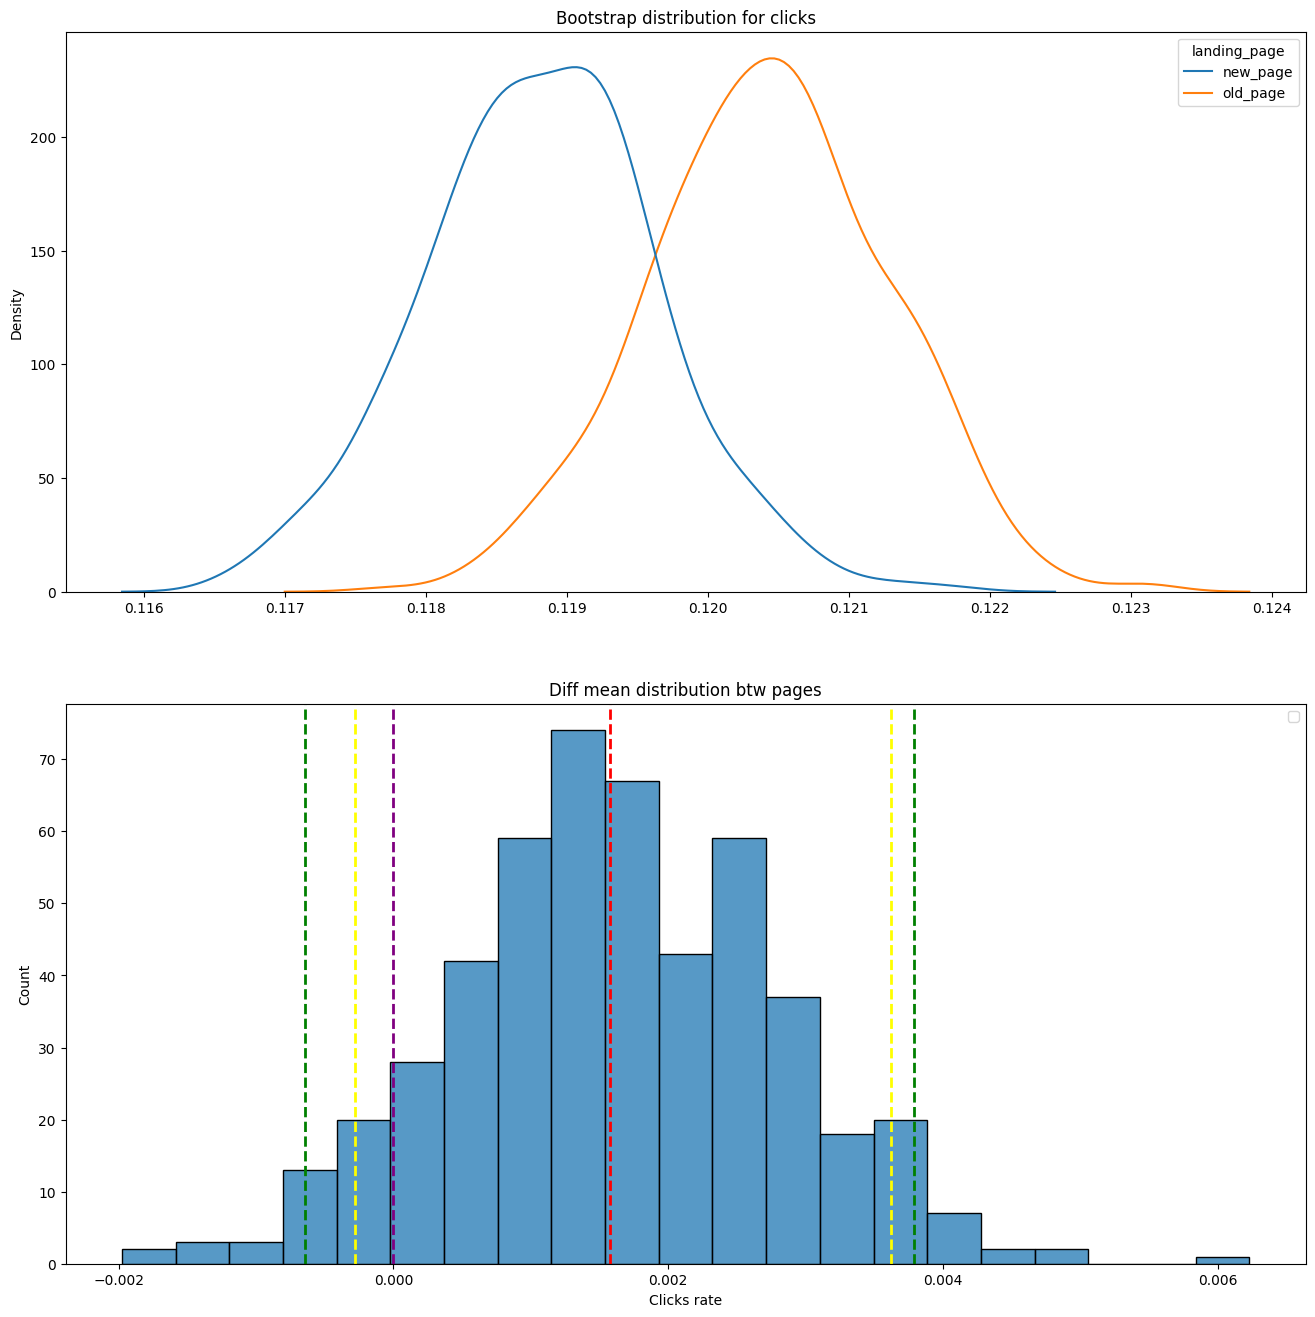

In [116]:
or_mean = cor_data[cor_data['landing_page'] == 'old_page']['converted'].mean() - cor_data[cor_data['landing_page'] == 'new_page']['converted'].mean()
or_mean

control_test_parameter = 'landing_page'

def bootstrap_metric(dataframe, control_test_p, metric, iterations = 500): 
    boot = []
    for i in range(iterations):
        boot_mean = dataframe.sample(frac=1, replace=True).groupby(control_test_p)[metric].mean()
        boot.append(boot_mean)
    boot = pd.DataFrame(boot)
    return boot

coverted = bootstrap_metric(dataframe=cor_data, control_test_p=control_test_parameter, metric='converted')
print((coverted['old_page'] - coverted['new_page']).quantile([0.025, 0.975]))
fig, axes = plt.subplots(2, 1, figsize=(16, 16))
plt.xlabel('Clicks rate')

sns.kdeplot(data=coverted, ax=axes[0])
axes[0].set_title('Bootstrap distribution for clicks')
coverted['diff'] = coverted['old_page'] - coverted['new_page']
sns.histplot(data=coverted['diff'], ax=axes[1])
axes[1].axvline(x=(coverted['old_page'] - coverted['new_page']).quantile(0.025), linewidth=2, color='green', linestyle='--')
axes[1].axvline(x=(coverted['old_page'] - coverted['new_page']).quantile(0.975), linewidth=2, color='green', linestyle='--')
axes[1].axvline(x=(coverted['old_page'] - coverted['new_page']).quantile(0.05), linewidth=2, color='yellow', linestyle='--')
axes[1].axvline(x=(coverted['old_page'] - coverted['new_page']).quantile(0.95), linewidth=2, color='yellow', linestyle='--')
axes[1].axvline(x=or_mean, linewidth=2, color='red', linestyle='--')
axes[1].axvline(x=0, linewidth=2, color='purple', linestyle='--')
axes[1].legend()
axes[1].set_title('Diff mean distribution btw pages')

plt.show()

    Как мы видим ноль входит в этот 95% интервал, то есть мы ничего не можем сказать о верности гипотезы, но 0 также попадает в 92 перцентиль, то есть компании следует скорее отказаться от фичи, так как она оказывает скорее негативное влияение, чем позитивное

### **Часть 2**

In [133]:
df = pd.read_csv('datasets/diabetic_data.csv')

In [134]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [136]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [137]:
df['patient_nbr'].unique()

array([  8222157,  55629189,  86047875, ..., 140199494, 120975314,
       175429310], shape=(71518,))

In [142]:
df[df['patient_nbr'].duplicated()]['patient_nbr']

79         23043240
81         21820806
143        41606064
175        86240259
307         5332491
            ...    
101760     50375628
101761    100162476
101762     74694222
101763     41088789
101764     31693671
Name: patient_nbr, Length: 30248, dtype: int64

    Так как некоторые пациенты записаны в датасет несколько раз, мы возьмем только первое посоещение

In [143]:
df = df.drop_duplicates('patient_nbr')

In [145]:
data_eda = df.copy()

    Слишком много пропусков/ не сособо важный для нашей рассматриваемой области факторы

In [146]:
del data_eda['weight'], data_eda['payer_code'], data_eda['medical_specialty'], data_eda['max_glu_serum'], data_eda['diag_1'], data_eda['diag_2'], data_eda['diag_3']

    Маска для вычисление retention в течении 30 дней, как самый главный показатель

In [148]:
d = {
    'NO':0,
    '<30':1,
    '>30':0
}

In [149]:
data_eda['retention'] = data_eda['readmitted'].map(d)
del data_eda['readmitted']

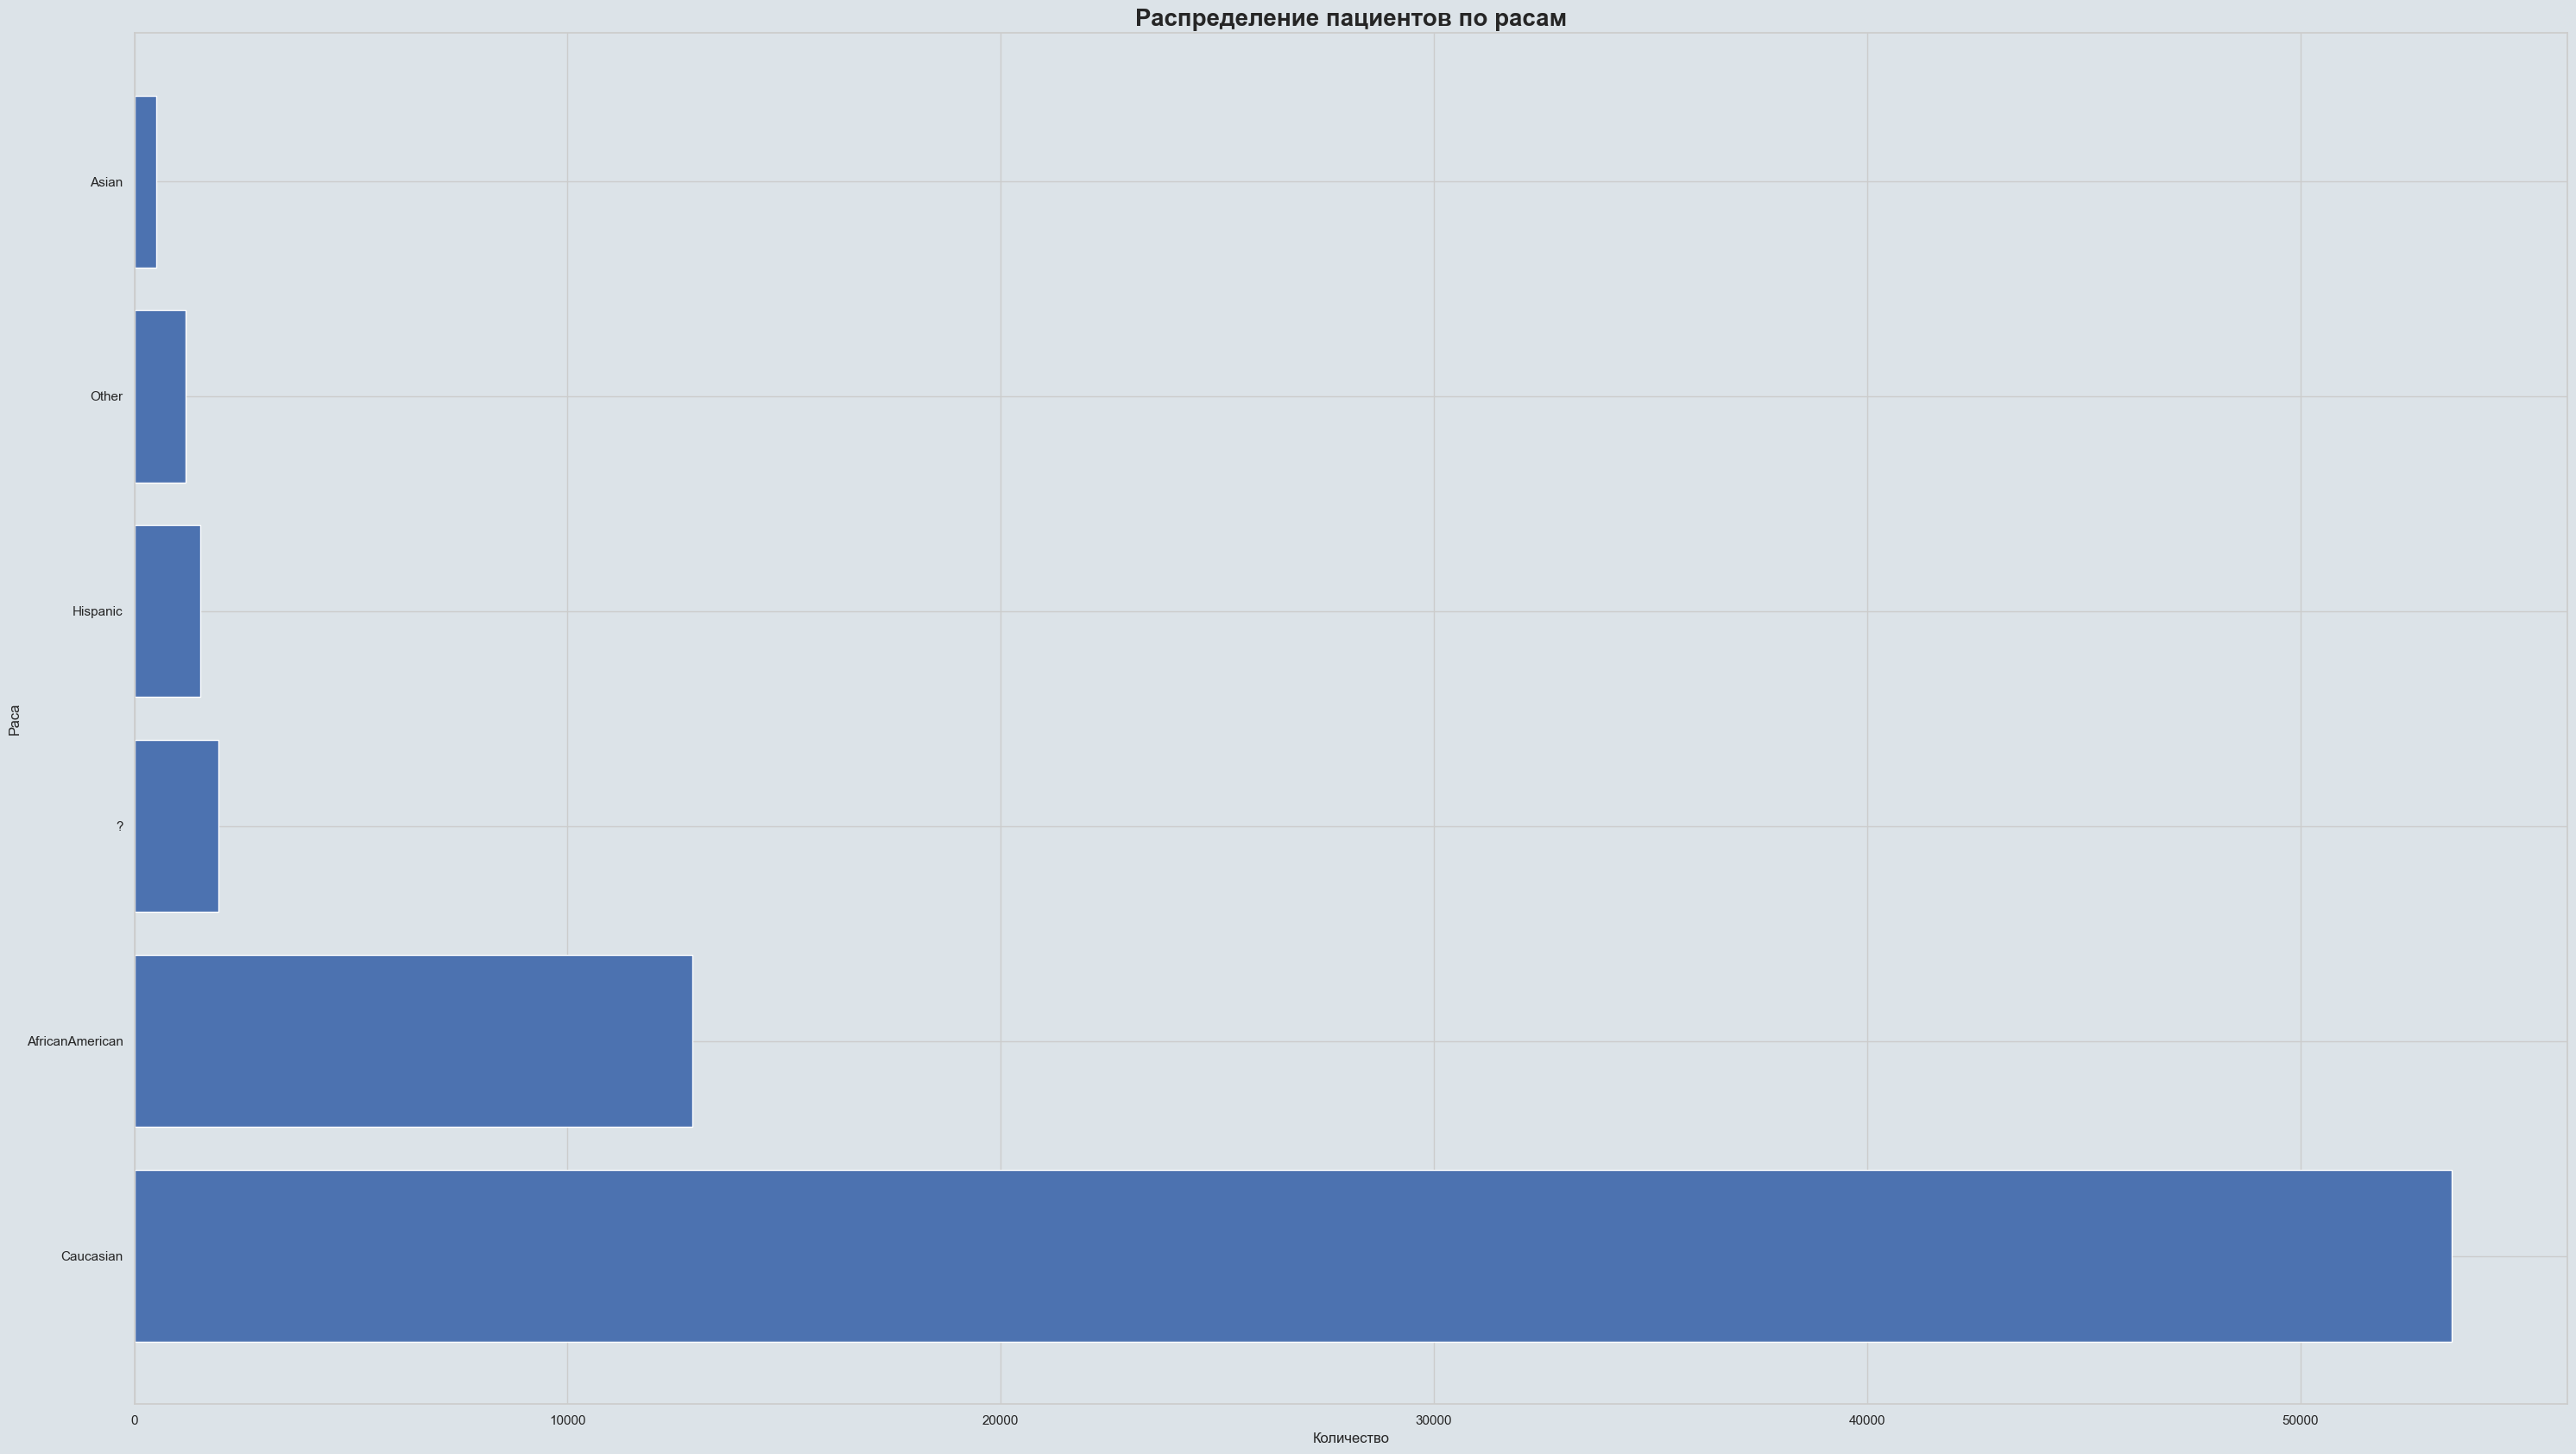

In [167]:
counts = data_eda['race'].value_counts()
plt.figure(figsize=(30, 17))

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#DCE3E8", 
    "axes.facecolor": "#DCE3E8"     
})
plt.barh(y=counts.index, width=counts.values)
plt.xlabel('Количество')
plt.ylabel('Раса')
plt.title('Распределение пациентов по расам', fontweight='bold', fontsize=20)
plt.tight_layout()
plt.show()

    В итоге был сделан выбор взять две наиболее представленные расы, а остальные объединить в other

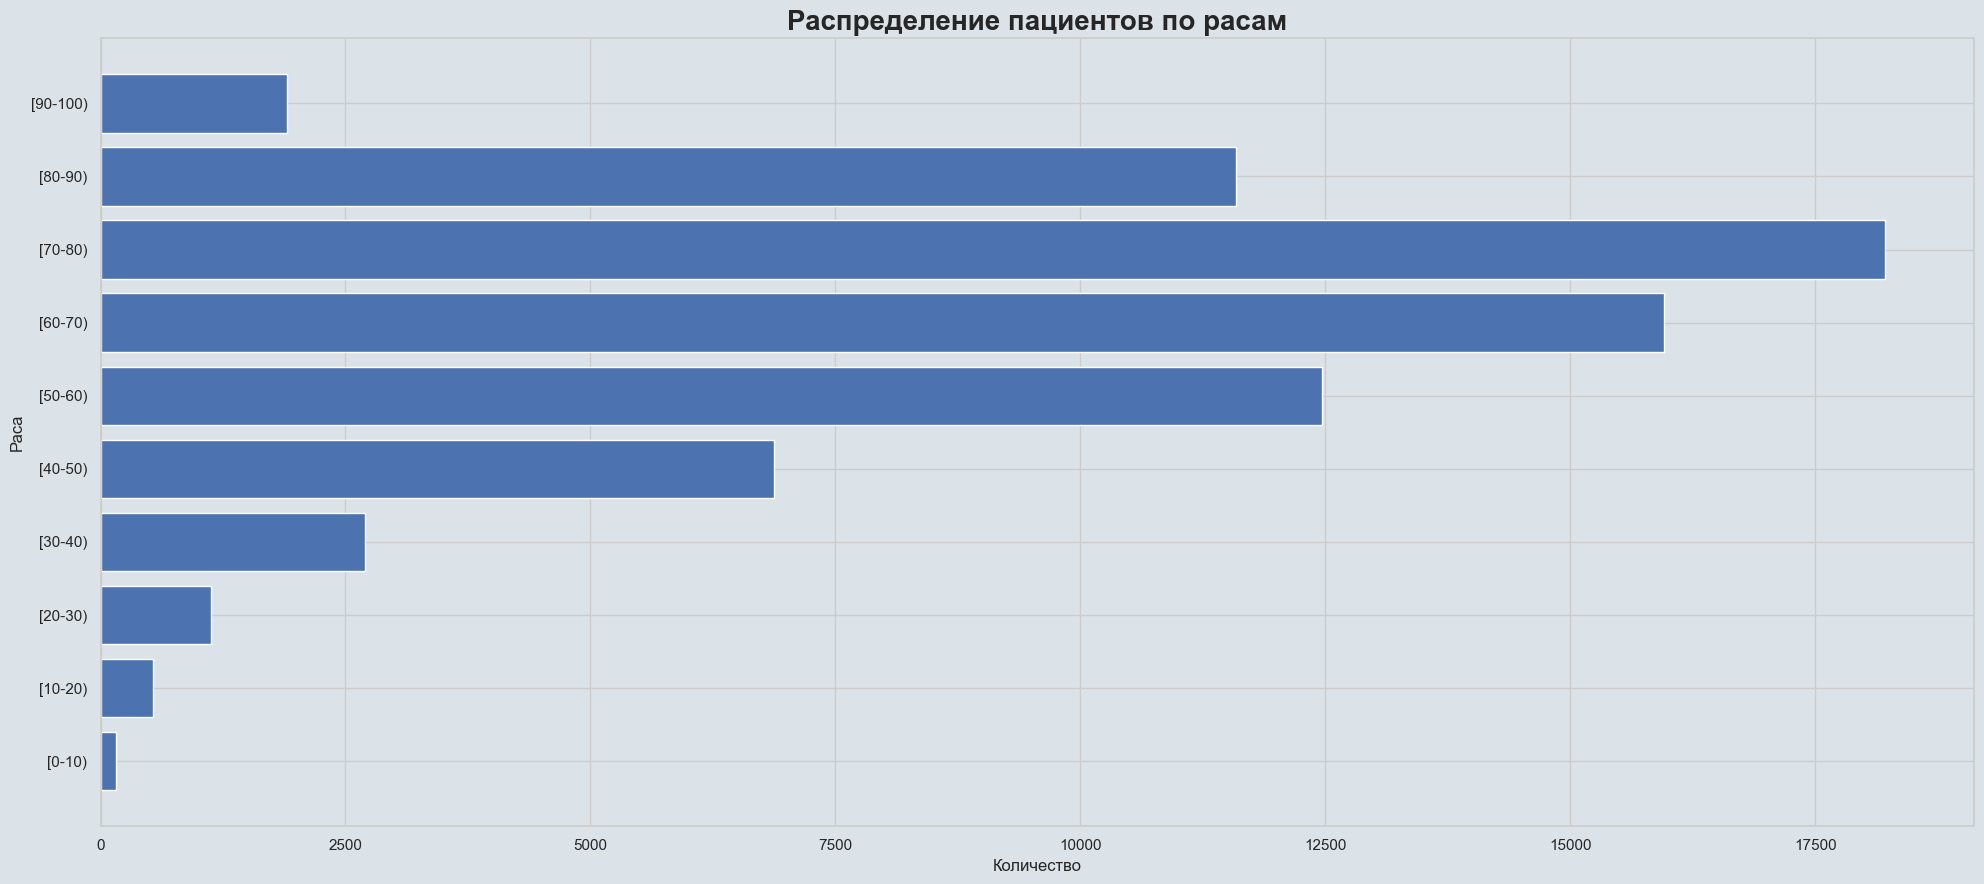

In [175]:
counts = data_eda['age'].value_counts().sort_index()
plt.figure(figsize=(20, 9))

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#DCE3E8", 
    "axes.facecolor": "#DCE3E8"     
})
plt.barh(y=counts.index, width=counts.values)
plt.xlabel('Количество')
plt.ylabel('Раса')
plt.title('Распределение пациентов по расам', fontweight='bold', fontsize=20)
plt.tight_layout()
plt.show()

    Как видно, наиболее представленная группа, люди > 50 лет, так как возвраст один из факторов заболевания диабетом, это вполне логично, в то время, как людей младше 30 лет представлено очень мало

    Объединим в группы 0-30, 30-60 и 60+ 

In [171]:
d_race = {
    "Asian":0,
    'Other':0,
    '?':'Missing',
    'Hispanic':0
}

In [176]:
d_age = {
    '[0-10)': 'less than 30y',
    '[10-20)': 'less than 30y',
    '[20-30)': 'less than 30y',
    '[30-40)': '30-60y',
    '[40-50)': '30-60y',
    '[50-60)': '30-60y',
    '[60-70)': '60y or more',
    '[70-80)': '60y or more',
    '[80-90)': '60y or more',
    '[90-100)': '60y or more'
}

In [172]:
data_eda['race'] = data_eda['race'].replace(d_race)

In [178]:
data_alive = data_eda[(data_eda['discharge_disposition_id'] != 11) & ((data_eda['discharge_disposition_id'] > 21) | (data_eda['discharge_disposition_id'] < 19))]

In [179]:
data_alive = data_alive[(data_alive['discharge_disposition_id'] != 13) & (data_alive['discharge_disposition_id'] != 14)]

In [188]:
data_alive['gender'].unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

In [190]:
data_alive = data_alive[data_alive['gender'] != 'Unknown/Invalid']

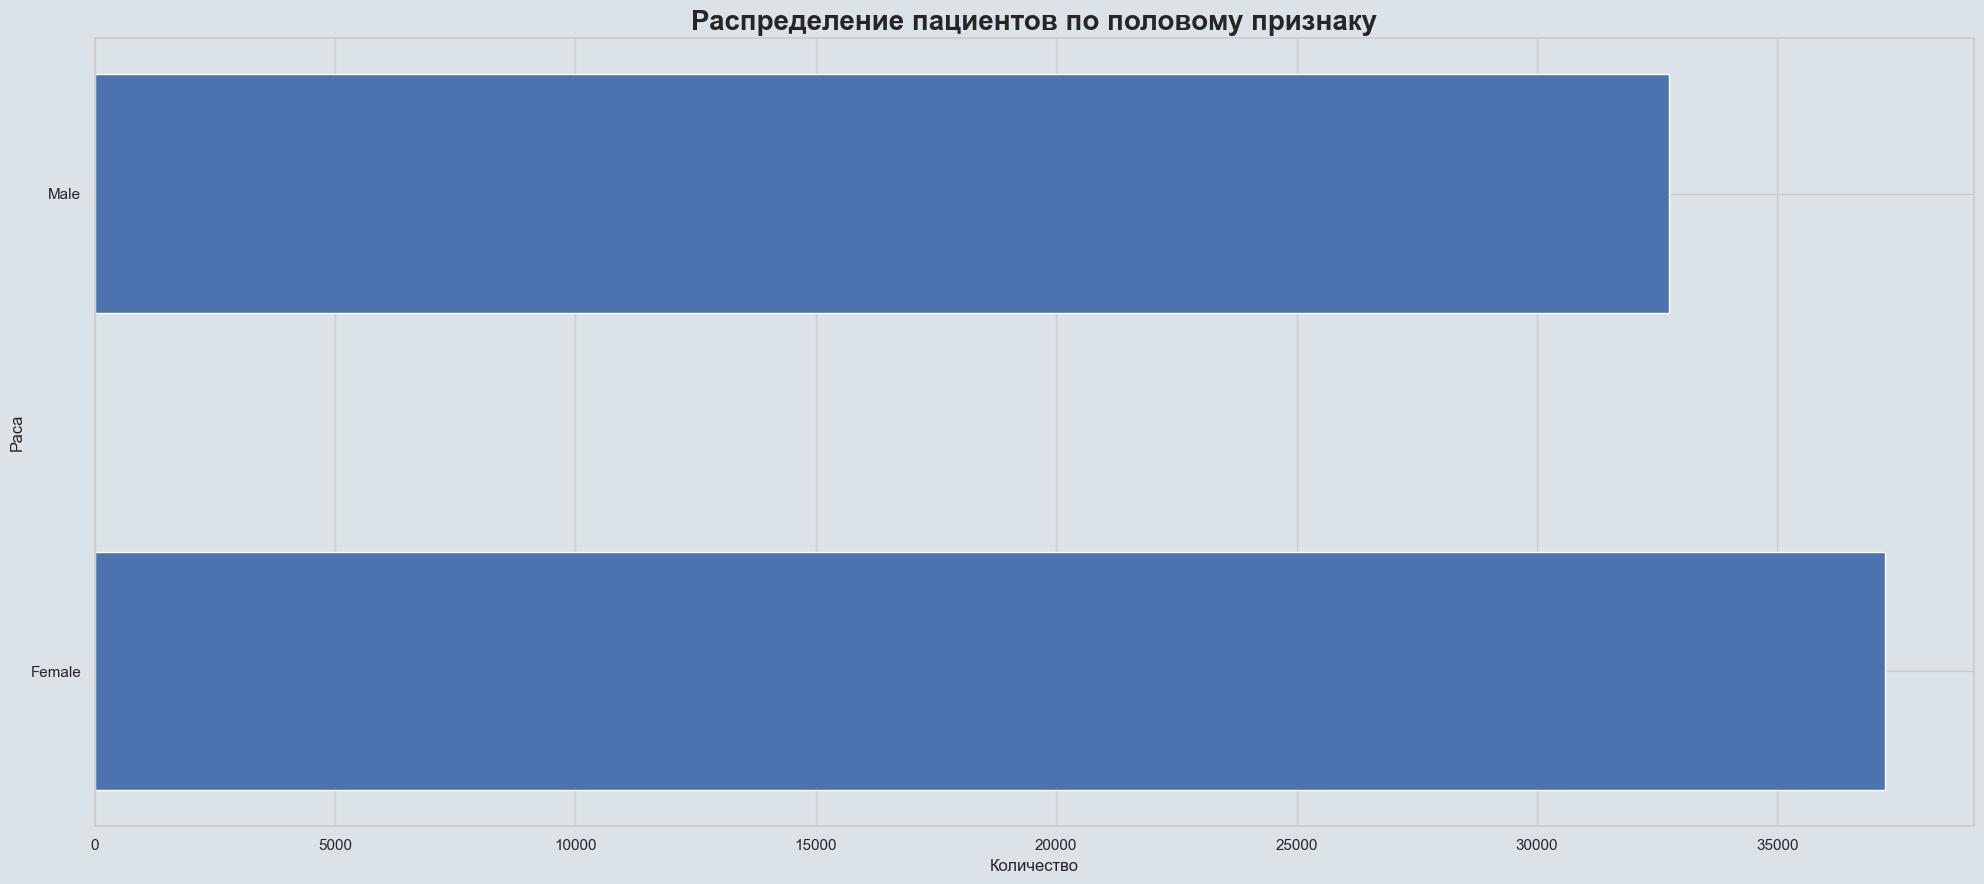

In [193]:
counts = data_alive['gender'].value_counts().sort_index()
plt.figure(figsize=(20, 9))

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#DCE3E8", 
    "axes.facecolor": "#DCE3E8"     
})
plt.barh(y=counts.index, width=counts.values, height=0.5)
plt.xlabel('Количество')
plt.ylabel('Раса')
plt.title('Распределение пациентов по половому признаку', fontweight='bold', fontsize=20)
plt.tight_layout()
plt.show()

In [14]:
df = pd.read_csv('datasets/final_dataset.csv')
df.drop(columns=['Unnamed: 0'])

,encounter_id,days_in_hospital,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,metformin,glipizide,glyburide,...,drugs_other,discharge_disposition_other,discharge_disposition_home,admission_other,admission_urgent,admission_elective,no_test,norm_result_test,high_result_test_and_change_meds,high_result_test_but_no_change_meds
0,2278392,1,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
1,149190,3,0,18,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
2,64410,2,5,13,2,0,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
3,500364,2,1,16,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
4,16680,1,0,8,0,0,0,0,1,0,...,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69965,443842016,9,2,33,0,0,0,0,0,1,...,0,0,1,0,1,0,0,0,1,0
69966,443842022,14,6,26,0,1,0,0,1,0,...,0,0,1,0,1,0,0,0,1,0
69967,443842070,2,6,17,1,1,1,0,0,0,...,0,0,1,0,1,0,1,0,0,0
69968,443842340,5,1,22,0,1,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0


In [196]:
group_a = data_alive[data_alive['gender'] == 'Male']['retention']
group_b = data_alive[data_alive['gender'] == 'Female']['retention']

In [197]:
g = pd.DataFrame({
    'retention': [group_a.mean(), group_b.mean()]
}, index=['Male', 'Female'])

In [16]:
df2 = pd.read_csv('datasets/data_severity.csv', index_col=0)
df = pd.merge(df, df2, on='encounter_id', how='left')

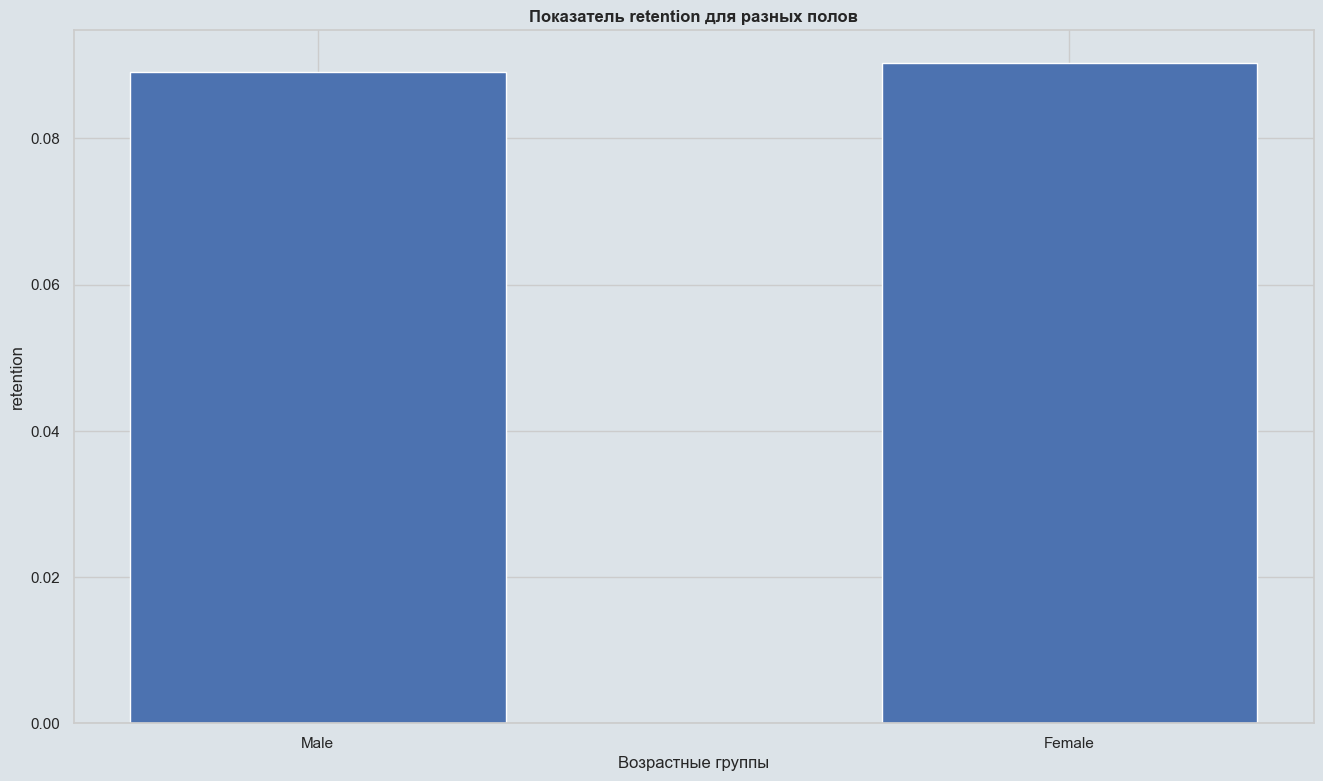

In [200]:
plt.figure(figsize=(16, 9))
plt.bar(g.index, g['retention'], width=0.5)
plt.ylabel('retention')
plt.xlabel('Возрастные группы')
plt.title('Показатель retention для разных полов', fontweight='bold')
plt.show()

In [17]:
df.columns

Index(['Unnamed: 0', 'encounter_id', 'days_in_hospital', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'metformin', 'glipizide', 'glyburide', 'insulin',
       'diabetesMed', 'retention', 'race_other', 'race_african_american',
       'race_caucasian', 'race_missing', 'sex_female', 'sex_male', '30-60y',
       '60y or more', 'less than 30y', 'drugs_other',
       'discharge_disposition_other', 'discharge_disposition_home',
       'admission_other', 'admission_urgent', 'admission_elective', 'no_test',
       'norm_result_test', 'high_result_test_and_change_meds',
       'high_result_test_but_no_change_meds', 'severity'],
      dtype='object')

**Гипотеза:**

У пациентов, с проведенным HbA1C тестом, своевременная коррекция терапии  является независимым фактором, снижающим риск ранней повторной госпитализации, даже после учета влияния возраста пациента, тяжести состояния  и типа поступления. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ

In [30]:
import statsmodels.api as sm

df_ml = df.copy()
df_ml['test_done'] = 1 - df_ml['no_test']

# Признаки
X = df_ml[[
    'test_done',#главный фактор
    '60y or more',
    'less than 30y',
    'severity',
    'admission_urgent'
]]

X = sm.add_constant(X)
y = df_ml['retention']

model = sm.Logit(y, X)
result = model.fit(disp=False, maxiter=1000)

print(result.summary())

                           Logit Regression Results                           
Dep. Variable:              retention   No. Observations:                69970
Model:                          Logit   Df Residuals:                    69964
Method:                           MLE   Df Model:                            5
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                0.005498
Time:                        02:47:17   Log-Likelihood:                -21005.
converged:                       True   LL-Null:                       -21122.
Covariance Type:            nonrobust   LLR p-value:                 3.516e-48
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.7712      0.041    -67.988      0.000      -2.851      -2.691
test_done           -0.0761      0.036     -2.142      0.032      -0.146      -0.006
60y or more          0.3499 

**Обобщающая модель:**

In [19]:
df.columns

Index(['Unnamed: 0', 'encounter_id', 'days_in_hospital', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'metformin', 'glipizide', 'glyburide', 'insulin',
       'diabetesMed', 'retention', 'race_other', 'race_african_american',
       'race_caucasian', 'race_missing', 'sex_female', 'sex_male', '30-60y',
       '60y or more', 'less than 30y', 'drugs_other',
       'discharge_disposition_other', 'discharge_disposition_home',
       'admission_other', 'admission_urgent', 'admission_elective', 'no_test',
       'norm_result_test', 'high_result_test_and_change_meds',
       'high_result_test_but_no_change_meds', 'severity'],
      dtype='object')

In [32]:
import statsmodels.api as sm

df_explain = df.copy()

features = [
    '60y or more', 'less than 30y',
    'high_result_test_and_change_meds',
    'high_result_test_but_no_change_meds',
    'norm_result_test', 'no_test',
    'num_medications', 'num_procedures',
    'number_emergency', 'number_inpatient', 'number_outpatient',
    'admission_urgent', 'admission_elective',
    'sex_male',
    'race_african_american', 'race_caucasian',
    'insulin', 'metformin',
    'severity'
]

X = sm.add_constant(df_explain[features])
y = df_explain['retention']


In [33]:
model = sm.Logit(y, X).fit(disp=False)

In [34]:
results = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params,
    'p_value': model.pvalues,
})

significant = results.query("p_value < 0.01 and feature != 'const'")
significant = significant.sort_values('coef', ascending=False)
print("Значимые признаки")
print(significant[['feature', 'p_value']].to_string(index=False))

Значимые признаки
              feature       p_value
     number_inpatient 3.268446e-106
          60y or more  2.055366e-27
race_african_american  9.612527e-03
       race_caucasian  8.266623e-03
             severity  2.021950e-04
     number_emergency  7.183037e-04
      num_medications  5.717055e-14
            metformin  3.599442e-03


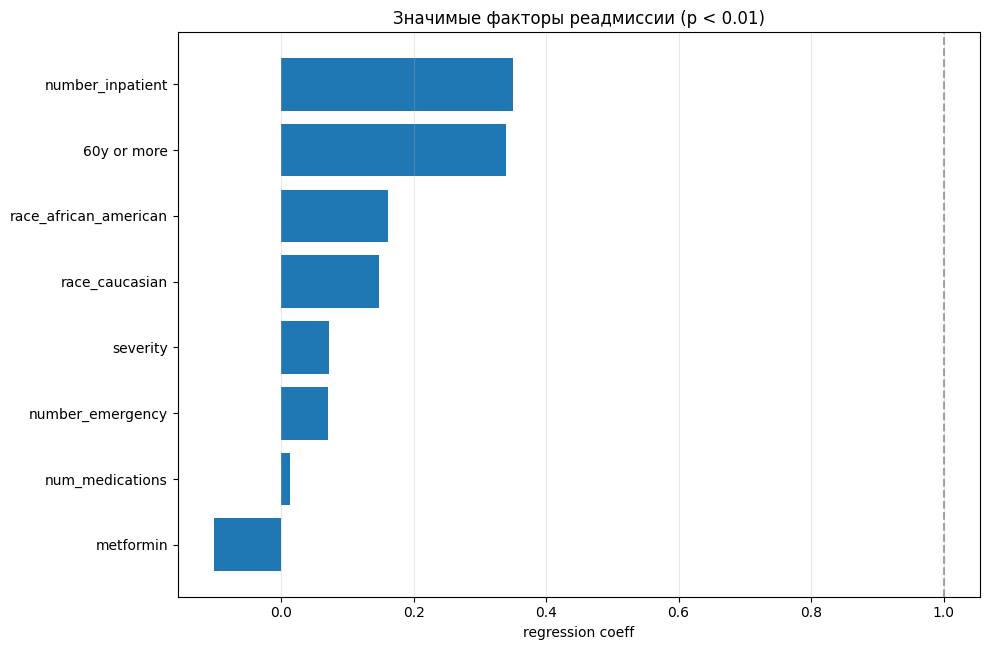

In [ ]:
plt.figure(figsize=(10, 0.45 * len(significant) + 3))

plt.axvline(1, linestyle='--', color='gray', alpha=0.7)
plt.barh(
    significant['feature'],
    significant['coef']
)

plt.xlabel('regression coeff')
plt.title('Значимые факторы реадмиссии (p < 0.01)', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

important_features = [
    '60y or more',
    'num_medications',
    'number_emergency',
    'number_inpatient',
    'race_african_american',
    'race_caucasian',
    'diabetesMed',
    'metformin'
]

df_explain = df_explain[df_explain['admission_urgent'] == 1]
X = df_explain[important_features].copy()
y = df_explain['retention']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

           0     0.9222    0.5925    0.7215     10967
           1     0.1099    0.5018    0.1804      1100

    accuracy                         0.5842     12067
   macro avg     0.5161    0.5472    0.4509     12067
weighted avg     0.8482    0.5842    0.6722     12067

Accuracy: 0.5842


Улучшаем

In [37]:
from sklearn.metrics import precision_recall_curve
y_proba = logreg.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall': recall[:-1]
})
pr_df['f1'] = (2 * pr_df['precision'] * pr_df['recall'])/(pr_df['precision'] + pr_df['recall'])

best_f1 = pr_df.sort_values('f1', ascending=False).iloc[0]
target_recall = 0.8

best_recall_threshold = pr_df[pr_df['recall'] >= target_recall].sort_values('precision', ascending=False).iloc[0]

threshold = best_recall_threshold['threshold']

y_pred_custom = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom, digits=4))

              precision    recall  f1-score   support

           0     0.9376    0.3014    0.4561     10967
           1     0.1030    0.8000    0.1825      1100

    accuracy                         0.3468     12067
   macro avg     0.5203    0.5507    0.3193     12067
weighted avg     0.8615    0.3468    0.4312     12067



После оптимизации порога классификации модель демонстрирует
способность выявлять ~70% пациентов с риском реадмиссии.
Несмотря на снижение accuracy, уменьшение количества ложно
отрицательных прогнозов делает модель более полезной
для клинического применения, где приоритетом является
минимизация пропусков реадмиссии.
